# [2] Download STAC Assets

> Download STAC Assets identified in the previous notebook.

__Notes:__

* The search and download phase was run on DBR17.3 AWS [m5d.xlarge](https://www.databricks.com/product/pricing/product-pricing/instance-types) instances (2-16 workers auto-scaling for up to 64 concurrent downloads).

---
__Last Update:__ April 17, 2026

### Imports + Config

In [0]:
%run ./config_nb

__Libraries__

* GeoBrix assumed already installed on the cluster.
* Python bindings now are `databricks.labs.gbx.rasterx` (etc).
* Pandas now at 2.2.3 with DBR17.3
* Match GDAL to version installed with natives (3.11.4).

__Unity Catalog__

* Replace `catalog_name` and `schema_name` with your preferred locations.
* Volume 'data' must exist under `catalog_name`/`schema_name`.

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


... catalog: 'geospatial_docs' (USE)
... schema: 'eo_series' (CREATE / USE)


... ETL_DIR: '/Volumes/geospatial_docs/eo_series/data'
... EO_DIR: '/Volumes/geospatial_docs/eo_series/data/alaska' (MKDIRS)


## Alaska STAC Asset Download

> We can easily extract the download links for items of interest. In this case, we will grab data within Alaska. Note: due to limitations in the [free tier for Planetary Computer](https://planetarycomputer.microsoft.com/docs/concepts/sas/), we will not attempt to get all available data within our time range. And to not make the example too large, we will just use a single county.

In [0]:
CELL_ASSET_DIR = None
LAST_UPDATED = None

# - previous write?
for r in os.listdir(EO_DIR):
  if r.startswith("cell_assets_"):
    LAST_UPDATED = r.split('_')[-1]
    CELL_ASSET_DIR = f"{EO_DIR}/{r}"
    break

os.environ['CELL_ASSET_DIR'] = CELL_ASSET_DIR

print(f"LAST_UPDATED: '{LAST_UPDATED}' [from working location] ->")
print(f"\tCELL_ASSET_DIR: '{CELL_ASSET_DIR}'")

LAST_UPDATED: '20251028-143135.delta' [from working location] ->
	CELL_ASSET_DIR: '/Volumes/geospatial_docs/eo_series/data/alaska/cell_assets_20251028-143135.delta'


In [0]:
eod_item_df = spark.read.load(CELL_ASSET_DIR)
print(f"count? {eod_item_df.count():,}")
eod_item_df.limit(1).show(vertical=True) # <- show + limiting for ipynb only

count? 336
-RECORD 0-------------------------------
 cellid          | 585797255290683391   
 geojson         | {"type":"Polygon"... 
 asset           | {name -> AOT, hre... 
 item_properties | {datetime -> 2022... 
 item_collection | sentinel-2-l2a       
 timestamp       | 2022-06-01 19:49:... 
 date            | 2022-06-01           
 item_bbox       | [-130.63956,55.84... 
 item_id         | S2A_MSIL2A_202206... 
 stac_version    | 1.1.0                
 last_update     | 20251028-143135      



_Notice that some assets overlap more than one h3 cellid._ __Function `download_band` consolidates to unique 'item_id' values vs focus on h3 cell(s) to avoid repeated download requests.__ 

In [0]:
bands = ['AOT',
 'B01',
 'B02',
 'B03',
 'B04',
 'B05',
 'B06',
 'B07',
 'B08',
 'B09',
 'B11',
 'B12',
 'B8A',
 'SCL',
 'WVP']

### Download bands for items 

> This will generate a table per band in the specified catalog and schema (set earlier in 'config_nb' notebook). __Note: We are invoking with `do_clean_files=False` to avoid wiping out already downloaded files; also, passing `False` for 'is_append_mode' param on the table generation side, but you can pass `True` to change.__

#### First - a Dry-Run

> Add all the columns that are added in the "live" execution, but we are specifying no actual execution (sanity check). __Note: we have nulls for `out_file_sz` (size) and `is_out_file_valid` since the files were not actually downloaded or checked.__

In [0]:
# - First, a do-nothing dry-run for sanity check...
# !!! NOTICE: do_clean_files, do_download, and do_table-write all FALSE !!!
b_df_dry = download_band(eod_item_df, bands[0], False, do_clean_files=False, do_download=False, do_table_write=False)
b_df_dry.limit(1).show(vertical=True) # <- show + limiting for ipynb only

	...shuffle partitions to 3 for this operation.
to_download count? 14
-RECORD 0---------------------------------
 item_id           | S2A_MSIL2A_202206... 
 timestamp         | 2022-06-01 19:49:... 
 h3_set            | [585797255290683391] 
 asset             | {name -> AOT, hre... 
 item_properties   | {datetime -> 2022... 
 item_collection   | sentinel-2-l2a       
 date              | 2022-06-01           
 item_bbox         | [-132.1276,54.182... 
 stac_version      | 1.1.0                
 last_update       | 20260417-200030      
 band_name         | AOT                  
 out_dir_fuse      | /Volumes/geospati... 
 out_filename      | AOT_S2A_MSIL2A_20... 
 out_file_path     | /Volumes/geospati... 
 out_file_sz       | NULL                 
 is_out_file_valid | NULL                 



#### Download bands of interest

> For this example series, we focus on B04 (red), B03 (green), B02 (blue), and B08 (nir). __You can easily download all / more.__

__Download Just 'B02'__

> We have `do_clean_files=False` to not overwrite any existing data (for repeated execution). The 'band_b02' metadata table is set to be overwritten with `append_mode` set to `False`. __Note: you can adjust this to append vs overwrite.__ Also, it is ok to interrupt and restart execution as files are first checked to see if they have already been downloaded to avoid unnecessary IOPS.

In [0]:
download_band(eod_item_df, 'B02', False, do_clean_files=False, do_download=True, do_table_write=True)

	...shuffle partitions to 3 for this operation.
to_download count? 14


DataFrame[item_id: string, timestamp: timestamp, h3_set: array<bigint>, asset: map<string,string>, item_properties: map<string,string>, item_collection: string, date: date, item_bbox: string, stac_version: string, last_update: string, band_name: string, out_dir_fuse: string, out_filename: string, out_file_path: string, out_file_sz: int, is_out_file_valid: boolean]

In [0]:
ls -1q $EO_DIR/B02 | wc -l

14


In [0]:
ls -lh $EO_DIR/B02

total 1.9G
-rwxrwxrwx 1 nobody nogroup  50M Oct 28 14:46 B02_S2A_MSIL2A_20220601T194911_R085_T08UPF_20220602T201121_20220601-194911.tif*
-rwxrwxrwx 1 nobody nogroup  61M Oct 28 14:46 B02_S2A_MSIL2A_20220601T194911_R085_T08UPG_20220602T195342_20220601-194911.tif*
-rwxrwxrwx 1 nobody nogroup  21M Oct 28 14:46 B02_S2A_MSIL2A_20220601T194911_R085_T08VPH_20220602T200243_20220601-194911.tif*
-rwxrwxrwx 1 nobody nogroup  88M Oct 28 14:46 B02_S2A_MSIL2A_20220601T194911_R085_T09UUA_20220602T180448_20220601-194911.tif*
-rwxrwxrwx 1 nobody nogroup 136M Oct 28 14:46 B02_S2A_MSIL2A_20220601T194911_R085_T09UUA_20220602T195601_20220601-194911.tif*
-rwxrwxrwx 1 nobody nogroup 200M Oct 28 14:46 B02_S2A_MSIL2A_20220601T194911_R085_T09UUB_20220602T200742_20220601-194911.tif*
-rwxrwxrwx 1 nobody nogroup 176M Oct 28 14:46 B02_S2A_MSIL2A_20220601T194911_R085_T09UUV_20220602T173354_20220601-194911.tif*
-rwxrwxrwx 1 nobody nogroup  38M Oct 28 14:47 B02_S2A_MSIL2A_20220601T194911_R085_T09UVA_20220602T164456_20

_Look at the band table generated for B02 [blue]._

In [0]:
%sql SELECT * from band_b02 limit 3

item_id,timestamp,h3_set,asset,item_properties,item_collection,date,item_bbox,stac_version,last_update,band_name,out_dir_fuse,out_filename,out_file_path,out_file_sz,is_out_file_valid
S2A_MSIL2A_20220601T194911_R085_T09UVA_20220602T195020,2022-06-01T19:49:11.024Z,List(585797255290683391),"Map(name -> B02, proj:shape -> [10980,10980], eo:bands -> [{""name"":""B02"",""common_name"":""blue"",""description"":""Band 2 - Blue"",""center_wavelength"":0.49,""full_width_half_max"":0.098}], roles -> [""data""], proj:bbox -> [399960.0,5990220.0,509760.0,6100020.0], gsd -> 10.0, title -> Band 2 - Blue - 10m, type -> image/tiff; application=geotiff; profile=cloud-optimized, href -> https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/09/U/VA/2022/06/01/S2A_MSIL2A_20220601T194911_N0400_R085_T09UVA_20220602T195020.SAFE/GRANULE/L2A_T09UVA_A036261_20220601T194908/IMG_DATA/R10m/T09UVA_20220601T194911_B02_10m.tif?st=2025-10-27T14%3A32%3A12Z&se=2025-10-28T15%3A17%3A12Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2025-10-28T13%3A55%3A51Z&ske=2025-11-04T13%3A55%3A51Z&sks=b&skv=2025-07-05&sig=enB8yRd/e72tZUAvw5c77aM5nHmCwxSbav1EL%2B4wTKk%3D, proj:transform -> [10.0,0.0,399960.0,0.0,-10.0,6100020.0])","Map(s2:mgrs_tile -> 09UVA, s2:datatake_type -> INS-NOBS, s2:nodata_pixel_percentage -> 3.830432, s2:snow_ice_percentage -> 12.346487, sat:orbit_state -> ascending, s2:product_uri -> S2A_MSIL2A_20220601T194911_N0400_R085_T09UVA_20220602T195020.SAFE, s2:generation_time -> 2022-06-02T19:50:20.750837Z, datetime -> 2022-06-01T19:49:11.024000Z, s2:datatake_id -> GS2A_20220601T194911_036261_N04.00, s2:vegetation_percentage -> 11.591592, sat:relative_orbit -> 85, s2:product_type -> S2MSI2A, s2:degraded_msi_data_percentage -> 0.0078, s2:high_proba_clouds_percentage -> 34.017438, s2:cloud_shadow_percentage -> 0.870197, s2:datastrip_id -> S2A_OPER_MSI_L2A_DS_ESRI_20220602T195022_S20220601T194908_N04.00, s2:mean_solar_azimuth -> 164.232568979234, eo:cloud_cover -> 65.520418, s2:granule_id -> S2A_OPER_MSI_L2A_TL_ESRI_20220602T195022_A036261_T09UVA_N04.00, proj:code -> EPSG:32609, s2:water_percentage -> 3.687096, s2:mean_solar_zenith -> 33.1542058157054, constellation -> Sentinel 2, s2:saturated_defective_pixel_percentage -> 0.0, s2:thin_cirrus_percentage -> 11.816428, s2:processing_baseline -> 04.00, s2:not_vegetated_percentage -> 1.282488, s2:unclassified_percentage -> 2.628108, platform -> Sentinel-2A, s2:reflectance_conversion_factor -> 0.973633779504449, instruments -> [""msi""], s2:dark_features_percentage -> 2.073612, s2:medium_proba_clouds_percentage -> 19.686551)",sentinel-2-l2a,2022-06-01,"[-130.5654,54.0551742,-128.84724,55.0468902]",1.1.0,20260417-200046,B02,/Volumes/geospatial_docs/eo_series/data/alaska/B02,B02_S2A_MSIL2A_20220601T194911_R085_T09UVA_20220602T195020_20220601-194911.tif,/Volumes/geospatial_docs/eo_series/data/alaska/B02/B02_S2A_MSIL2A_20220601T194911_R085_T09UVA_20220602T195020_20220601-194911.tif,213612077,true
S2A_MSIL2A_20220601T194911_R085_T08UPG_20220602T195342,2022-06-01T19:49:11.024Z,List(585797255290683391),"Map(name -> B02, proj:shape -> [10980,10980], eo:bands -> [{""name"":""B02"",""common_name"":""blue"",""description"":""Band 2 - Blue"",""center_wavelength"":0.49,""full_width_half_max"":0.098}], roles -> [""data""], proj:bbox -> [600000.0,6090240.0,709800.0,6200040.0], gsd -> 10.0, title -> Band 2 - Blue - 10m, type -> image/tiff; application=geotiff; profile=cloud-optimized, href -> https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/08/U/PG/2022/06/01/S2A_MSIL2A_20220601T194911_N0400_R085_T08UPG_20220602T195342.SAFE/GRANULE/L2A_T08UPG_A036261_20220601T194908/IMG_DATA/R10m/T08UPG_20220601T194911_B02_10m.tif?st=2025-10-27T14%3A32%3A12Z&se=2025-10-28T15%3A17%3A12Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2025-10-28T13%3A55%3A51Z&ske=2025-11-04T13%3A55%3A51Z&sks=b&skv=2025-07

_Look at a couple of the band GeoTIFFs._

In [0]:
ex_bands = [t[0] for t in spark.table('band_b02').select('out_file_path').limit(2).collect()]
(
  spark.table("band_b02")
  .where(
    col("out_file_path").isin(ex_bands)
  )
).limit(2).show(vertical=True) # <- show + limiting for ipynb only

-RECORD 0---------------------------------
 item_id           | S2A_MSIL2A_202206... 
 timestamp         | 2022-06-01 19:49:... 
 h3_set            | [585797255290683391] 
 asset             | {name -> B02, hre... 
 item_properties   | {datetime -> 2022... 
 item_collection   | sentinel-2-l2a       
 date              | 2022-06-01           
 item_bbox         | [-130.5654,54.055... 
 stac_version      | 1.1.0                
 last_update       | 20260417-200046      
 band_name         | B02                  
 out_dir_fuse      | /Volumes/geospati... 
 out_filename      | B02_S2A_MSIL2A_20... 
 out_file_path     | /Volumes/geospati... 
 out_file_sz       | 213612077            
 is_out_file_valid | true                 
-RECORD 1---------------------------------
 item_id           | S2A_MSIL2A_202206... 
 timestamp         | 2022-06-01 19:49:... 
 h3_set            | [585797255290683391] 
 asset             | {name -> B02, hre... 
 item_properties   | {datetime -> 2022... 
 item_colle

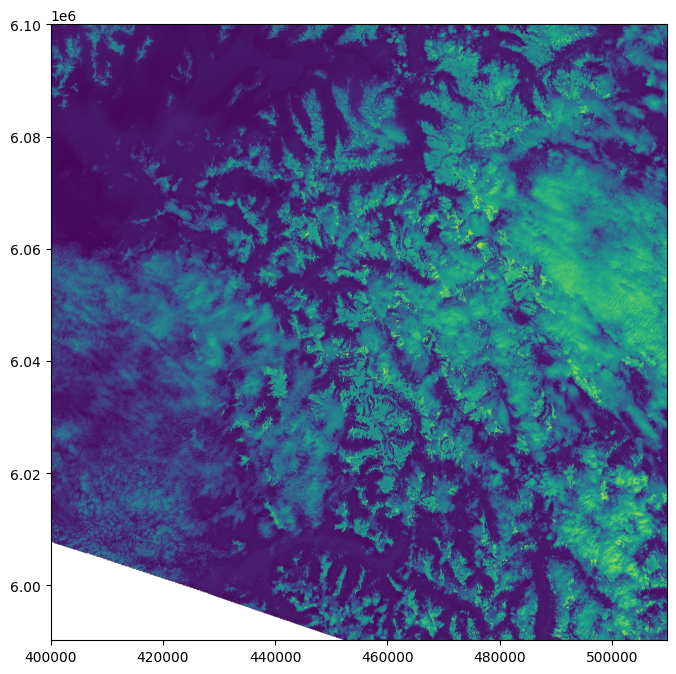

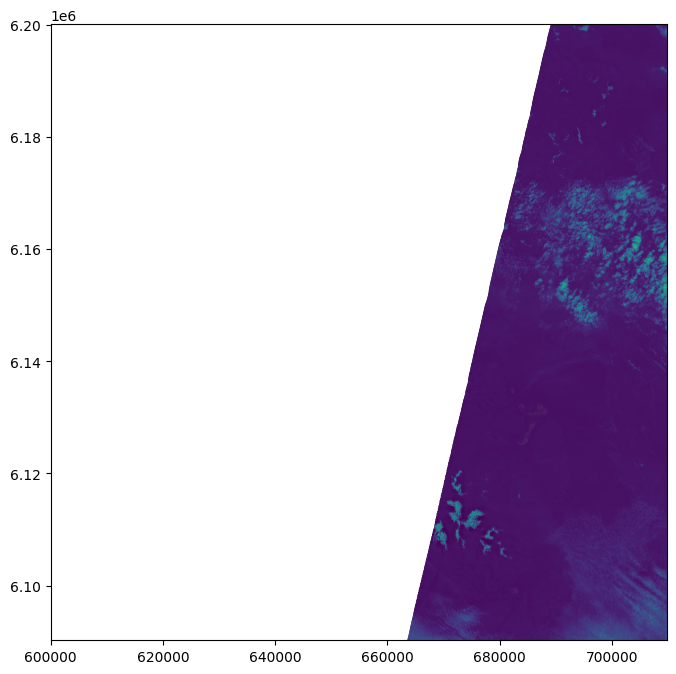

In [0]:
for b in ex_bands:
  library.plot_file(b)

In [0]:
print(f"""b02 total count? {sql("select format_number(count(1),0) from band_b02").first()[0]}""")
print(f"""b02 valid count? {sql("select format_number(count(1),0) from band_b02 where is_out_file_valid").first()[0]}""")
print(f"""b02 false count? {sql("select format_number(count(1),0) from band_b02 where is_out_file_valid = False").first()[0]}""")
print(f"""b02 null count?  {sql("select format_number(count(1),0) from band_b02 where is_out_file_valid is null").first()[0]}""")

b02 total count? 14
b02 valid count? 14
b02 false count? 0
b02 null count?  0


#### Optional: Fix Missing Data

> As a result of being gated in the free tier to Planetary Computure, a number of attempts to download band data might have resulted in an message versus the actual data (no failure condition provided). Here is what that might look like:

```
<?xml version="1.0" encoding="utf-8"?><Error><Code>AuthenticationFailed</Code><Message>Server failed to authenticate the request. Make sure the value of Authorization header is formed correctly including the signature.
RequestId:bf21b919-d01e-002f-4e00-2ae765000000
Time:2023-12-08T18:04:30.9365583Z</Message><AuthenticationErrorDetail>Signature not valid in the specified time frame: Start [Thu, 07 Dec 2023 17:18:15 GMT] - Expiry [Fri, 08 Dec 2023 18:03:15 GMT] - Current [Fri, 08 Dec 2023 18:04:30 GMT]</AuthenticationErrorDetail></Error>
```

The size is around 550 bytes, so we can test for this and smartly retry.

__Note:__ We are using Delta Lake MERGE support to udate a given band table [[1](https://docs.databricks.com/en/delta/merge.html#language-python)].

__Since 'B02' (blue) now has all data, let's turn to 'B03' (green).__

> Initially, we set `do_download=False` and `do_table_write` to demonstrate how this table can be filled in with a subsequent call to `download_missing_assets(...)` or `update_assets(...)`. __Note; 'out_file_sz' and 'is_out_file_valid' are both set to `Null` because we have not yet calculated this information (e.g. there may be some pre-existing files).__

In [0]:
# - example of a table write without file download
(
  download_band(eod_item_df, 'B03', False, do_clean_files=False, do_download=False, do_table_write=True)
    .limit(1)
    .show(vertical=True) # <- show + limiting for ipynb only
)

	...shuffle partitions to 3 for this operation.
to_download count? 14
-RECORD 0---------------------------------
 item_id           | S2A_MSIL2A_202206... 
 timestamp         | 2022-06-01 19:49:... 
 h3_set            | [585797255290683391] 
 asset             | {name -> B03, hre... 
 item_properties   | {datetime -> 2022... 
 item_collection   | sentinel-2-l2a       
 date              | 2022-06-01           
 item_bbox         | [-132.0596,53.123... 
 stac_version      | 1.1.0                
 last_update       | 20260417-200305      
 band_name         | B03                  
 out_dir_fuse      | /Volumes/geospati... 
 out_filename      | B03_S2A_MSIL2A_20... 
 out_file_path     | /Volumes/geospati... 
 out_file_sz       | NULL                 
 is_out_file_valid | NULL                 



In [0]:
%sql 
-- notice the table was written
-- but no files downloaded
select * from band_b03 limit 1

item_id,timestamp,h3_set,asset,item_properties,item_collection,date,item_bbox,stac_version,last_update,band_name,out_dir_fuse,out_filename,out_file_path,out_file_sz,is_out_file_valid
S2A_MSIL2A_20220601T194911_R085_T09UUV_20220602T173354,2022-06-01T19:49:11.024Z,List(585797255290683391),"Map(name -> B03, proj:shape -> [10980,10980], eo:bands -> [{""name"":""B03"",""common_name"":""green"",""description"":""Band 3 - Green"",""center_wavelength"":0.56,""full_width_half_max"":0.045}], roles -> [""data""], proj:bbox -> [300000.0,5890200.0,409800.0,6000000.0], gsd -> 10.0, title -> Band 3 - Green - 10m, type -> image/tiff; application=geotiff; profile=cloud-optimized, href -> https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/09/U/UV/2022/06/01/S2A_MSIL2A_20220601T194911_N0400_R085_T09UUV_20220602T173354.SAFE/GRANULE/L2A_T09UUV_A036261_20220601T195947/IMG_DATA/R10m/T09UUV_20220601T194911_B03_10m.tif?st=2025-10-27T14%3A32%3A12Z&se=2025-10-28T15%3A17%3A12Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2025-10-28T13%3A55%3A51Z&ske=2025-11-04T13%3A55%3A51Z&sks=b&skv=2025-07-05&sig=enB8yRd/e72tZUAvw5c77aM5nHmCwxSbav1EL%2B4wTKk%3D, proj:transform -> [10.0,0.0,300000.0,0.0,-10.0,6000000.0])","Map(s2:mgrs_tile -> 09UUV, s2:datatake_type -> INS-NOBS, s2:nodata_pixel_percentage -> 0.0, s2:snow_ice_percentage -> 0.001138, sat:orbit_state -> descending, s2:product_uri -> S2A_MSIL2A_20220601T194911_N0400_R085_T09UUV_20220602T173354.SAFE, s2:generation_time -> 2022-06-02T17:33:54.313131Z, datetime -> 2022-06-01T19:49:11.024000Z, s2:datatake_id -> GS2A_20220601T194911_036261_N04.00, s2:vegetation_percentage -> 7.600781, sat:relative_orbit -> 85, s2:product_type -> S2MSI2A, s2:degraded_msi_data_percentage -> 0.0, s2:high_proba_clouds_percentage -> 30.163026, s2:cloud_shadow_percentage -> 0.152767, s2:datastrip_id -> S2A_OPER_MSI_L2A_DS_ESRI_20220602T173354_S20220601T195947_N04.00, s2:mean_solar_azimuth -> 161.42990416574, eo:cloud_cover -> 73.291171, s2:granule_id -> S2A_OPER_MSI_L2A_TL_ESRI_20220602T173354_A036261_T09UUV_N04.00, proj:code -> EPSG:32609, s2:water_percentage -> 18.306021, s2:mean_solar_zenith -> 32.5238086562375, constellation -> Sentinel 2, s2:saturated_defective_pixel_percentage -> 0.0, s2:thin_cirrus_percentage -> 5.371973, s2:processing_baseline -> 04.00, s2:not_vegetated_percentage -> 0.368592, s2:unclassified_percentage -> 0.235009, platform -> Sentinel-2A, s2:reflectance_conversion_factor -> 0.973633779504449, instruments -> [""msi""], s2:dark_features_percentage -> 0.044525, s2:medium_proba_clouds_percentage -> 37.756169)",sentinel-2-l2a,2022-06-01,"[-132.0596,53.12364504,-130.34888,54.14018678]",1.1.0,20260417-200305,B03,/Volumes/geospatial_docs/eo_series/data/alaska/B03,B03_S2A_MSIL2A_20220601T194911_R085_T09UUV_20220602T173354_20220601-194911.tif,/Volumes/geospatial_docs/eo_series/data/alaska/B03/B03_S2A_MSIL2A_20220601T194911_R085_T09UUV_20220602T173354_20220601-194911.tif,null,null


_See all for field 'is_out_file_valid' are `null`._

In [0]:
print(f"""b03 total count? {sql("select format_number(count(1),0) from band_b03").first()[0]}""")
print(f"""b03 valid count? {sql("select format_number(count(1),0) from band_b03 where is_out_file_valid = True").first()[0]}""")
print(f"""b03 false count? {sql("select format_number(count(1),0) from band_b03 where is_out_file_valid = False").first()[0]}""")
print(f"""b03 null count?  {sql("select format_number(count(1),0) from band_b03 where is_out_file_valid is null").first()[0]}""")

b03 total count? 14
b03 valid count? 0
b03 false count? 0
b03 null count?  14


_A dry-run of a single item..._

In [0]:
test_item_id = spark.table('band_b02').select('item_id').first()[0] # <- get an example from b02
test_item_id

'S2A_MSIL2A_20220601T194911_R085_T09UVA_20220602T195020'

In [0]:
(
  download_missing_assets(
    "band_b03", 
    where_clause=f"item_id = '{test_item_id}'", 
    do_dry_run=True
  )
  .limit(1)
  .show(vertical=True) # <- show + limiting for ipynb only
)

-RECORD 0---------------------------------
 item_id           | S2A_MSIL2A_202206... 
 timestamp         | 2022-06-01 19:49:... 
 h3_set            | [585797255290683391] 
 asset             | {name -> B03, hre... 
 item_properties   | {datetime -> 2022... 
 item_collection   | sentinel-2-l2a       
 date              | 2022-06-01           
 item_bbox         | [-130.5654,54.055... 
 stac_version      | 1.1.0                
 last_update       | 20260417-200305      
 band_name         | B03                  
 out_dir_fuse      | /Volumes/geospati... 
 out_filename      | B03_S2A_MSIL2A_20... 
 out_file_path     | /Volumes/geospati... 
 out_file_sz       | NULL                 
 is_out_file_valid | NULL                 



_Actual run of a single item..._

```
(
  download_missing_assets(
    "band_b03", 
    where_clause=f"item_id = '{test_item_id}'", 
    do_dry_run=False 
  )
)
```

_The `where_clause` param is optional in `download_missing_assets(...)`, when not specified, all data where 'is_out_file_valid' is not True will be tested and (re)downloaded as needed._ __Note: merges can be a more expensive, so do testing to see which option (including the one below), meets your needs.__

### Download Any / All Other Bands

> This call will get all the bands; it can be rerun to download any missing files also. __Note: `append_mode` is `False`, meaning it will overwrite the current band table, but we set `do_clean_files=False` so it will just download new / missing files.__ 

_This downloads ~380 GeoTIFFs per band per day for the state of Alaska (__we are just doing a county in this example__). The operation can take some time, especially depending on (1) the size of your cluster, (2) whether starting fresh, and (3) how impacted you are by the free tier limits / throttling._ Also, sometimes an executor on the cluster might hang due to the nature of these longer running jobs (and the phased up delays from throttling). In the even that a task is hung up for say 15+ minutes, e.g. 511/512 tasks having completed, it is ok to interrupt and restart execution as files are first checked to see if they have already been downloaded, so the operation can recover without to much duplicated time / processing.

In [0]:
# - uncomment when ready
for band in ['B02', 'B03', 'B04', 'B08']:
    print(f"working on band '{band}'...")
    download_band(eod_item_df, band, False, do_clean_files=False, do_download=True, do_table_write=True)

display(dbutils.fs.ls(f"{EO_DIR}"))

working on band 'B02'...
	...shuffle partitions to 3 for this operation.
to_download count? 14
working on band 'B03'...
	...shuffle partitions to 3 for this operation.
to_download count? 14
working on band 'B04'...
	...shuffle partitions to 3 for this operation.
to_download count? 14
working on band 'B08'...
	...shuffle partitions to 3 for this operation.
to_download count? 14


path,name,size,modificationTime
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B02/,B02/,0,1776456478304
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B03/,B03/,0,1776456478304
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B04/,B04/,0,1776456478304
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B08/,B08/,0,1776456478304
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/cell_assets_20251028-143135.delta/,cell_assets_20251028-143135.delta/,0,1776456478304
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/out/,out/,0,1776456478304


_Verify we have all data for bands._

In [0]:
for band in ['B02', 'B03', 'B04', 'B08']:
  print(f"::: '{band}' :::")
  df_band = spark.table(f"band_{band}")
  print(f"""\ttotal?            {df_band.count():,}""")
  print(f"""\tis valid?         {df_band.filter(F.expr("is_out_file_valid = True")).count():,}""")
  print(f"""\tnot valid?        {df_band.filter(F.expr("is_out_file_valid = False")).count():,}""")
  print(f"""\tunknown validity? {df_band.filter(F.expr("is_out_file_valid is null")).count():,}""")
  print("")

::: 'B02' :::
	total?            14
	is valid?         14
	not valid?        0
	unknown validity? 0

::: 'B03' :::
	total?            14
	is valid?         14
	not valid?        0
	unknown validity? 0

::: 'B04' :::
	total?            14
	is valid?         14
	not valid?        0
	unknown validity? 0

::: 'B08' :::
	total?            14
	is valid?         14
	not valid?        0
	unknown validity? 0



_See all the tables generated._

In [0]:
%sql show tables

database,tableName,isTemporary
eo_series,band_b02,false
eo_series,band_b02_h3,false
eo_series,band_b02_tile,false
eo_series,band_b03,false
eo_series,band_b03_h3,false
eo_series,band_b03_tile,false
eo_series,band_b04,false
eo_series,band_b04_h3,false
eo_series,band_b04_tile,false
eo_series,band_b08,false


_Look at the directories where the bands were downloaded._

In [0]:
display(dbutils.fs.ls(EO_DIR))

path,name,size,modificationTime
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B02/,B02/,0,1776456508368
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B03/,B03/,0,1776456508368
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B04/,B04/,0,1776456508368
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B08/,B08/,0,1776456508368
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/cell_assets_20251028-143135.delta/,cell_assets_20251028-143135.delta/,0,1776456508368
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/out/,out/,0,1776456508368
